In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import random

seed = 100

random.seed(seed)


np.random.seed(seed)

torch.manual_seed(seed)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
env = gym.make('Acrobot-v1')
state, info = env.reset(seed=seed)
env.action_space.seed(seed)
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Hyperparameters adjusted for Acrobot-v1
REPLAY_MEMORY_SIZE = 10000 # adjusted
BATCH_SIZE = 32  # the same as paper
GAMMA = 0.99    # the same as paper
TARGET_UPDATE_FREQ = 100  # adjusted
LEARNING_RATE = 0.00025    # the same as paper
RMS_DECAY = 0.95      # the same as paper
RMS_MOMENTUM = 0.95   # the same as paper
RMS_EPSILON = 0.01   # the same as paper
EPSILON_START = 1.0   # the same as paper
EPSILON_END = 0.1    # the same as paper
EPSILON_DECAY_STEPS = 2000   # adjusted
Experience = namedtuple('Experience', field_names=['state', 'action', 'reward', 'next_state', 'done'])

Using device: cuda


In [2]:
class QNetwork(nn.Module):
    def __init__(self):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [3]:
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append(Experience(state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [4]:
class DQNAgent:
    def __init__(self):
        self.policy_net = QNetwork().to(device)
        self.target_net = QNetwork().to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.RMSprop(
            self.policy_net.parameters(),
            lr=LEARNING_RATE,
            alpha=RMS_DECAY,
            momentum=RMS_MOMENTUM,
            eps=RMS_EPSILON,
            centered=False
        )

        self.memory = ReplayMemory(REPLAY_MEMORY_SIZE)
        self.step_count = 0
    def select_action(self, state, epsilon):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)

        if random.random() > epsilon:
            with torch.no_grad():
                return self.policy_net(state).max(1)[1].item()
        else:
            return random.randrange(action_size)

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return

        experiences = self.memory.sample(BATCH_SIZE)
        batch = Experience(*zip(*experiences))

        state_batch = torch.FloatTensor(np.array(batch.state)).to(device)
        action_batch = torch.LongTensor(np.array(batch.action)).unsqueeze(1).to(device)
        reward_batch = torch.FloatTensor(np.array(batch.reward)).unsqueeze(1).to(device)
        next_state_batch = torch.FloatTensor(np.array(batch.next_state)).to(device)
        done_batch = torch.FloatTensor(np.array(batch.done)).unsqueeze(1).to(device)

        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        with torch.no_grad():
            next_state_values = self.target_net(next_state_batch).max(1)[0].unsqueeze(1)

        expected_state_action_values = torch.where(
            done_batch == 1,
            reward_batch,
            reward_batch + GAMMA * next_state_values
        )

        loss = nn.SmoothL1Loss()(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1

        if self.step_count % TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

In [5]:
def train(num_episodes=500, max_steps=500, agent=None):
    if agent is None:
        agent = DQNAgent()
    scores = []
    total_steps = 0
    epoch_size = 10
    epoch_scores = []

    print(f"Starting DQN training for Acrobot-v1")

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset()
        total_reward = 0

        for t in range(max_steps):
            decay_progress = min(total_steps / EPSILON_DECAY_STEPS, 1.0)
            current_epsilon = EPSILON_START - decay_progress * (EPSILON_START - EPSILON_END)
            epsilon = max(EPSILON_END, current_epsilon)

            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            total_steps += 1

            agent.optimize_model()

            if done:
                break

        scores.append(total_reward)

        # Calculate epoch scores
        if episode % epoch_size == 0:
            epoch_scores.append(np.mean(scores[-epoch_size:]))
            print(f"Epoch {len(epoch_scores)}, Average score: {epoch_scores[-1]:.2f}, Epsilon: {epsilon:.3f}, steps: {total_steps}")

        if episode % 100 == 0:
            avg_score = np.mean(scores[-100:])
            print(f"Episode {episode}\tAverage Score (100 episodes): {avg_score:.2f}")

        # Acrobot-v1 is considered solved when average reward over 100 episodes is >= -100
        if episode >= 100 and np.mean(scores[-100:]) >= -100.0:
            print(f"\nEnvironment solved in {episode} episodes. Average Score (100 episodes): {np.mean(scores[-100:]):.2f}")
            break

    return scores, epoch_scores


--- Running baseline with default parameters ---
Starting DQN training for Acrobot-v1
Epoch 1, Average score: -388.30, Epsilon: 0.100, steps: 3889
Epoch 2, Average score: -203.10, Epsilon: 0.100, steps: 5930
Epoch 3, Average score: -204.70, Epsilon: 0.100, steps: 7987
Epoch 4, Average score: -310.90, Epsilon: 0.100, steps: 11105
Epoch 5, Average score: -265.60, Epsilon: 0.100, steps: 13771
Epoch 6, Average score: -193.10, Epsilon: 0.100, steps: 15712
Epoch 7, Average score: -150.50, Epsilon: 0.100, steps: 17227
Epoch 8, Average score: -160.50, Epsilon: 0.100, steps: 18842
Epoch 9, Average score: -132.00, Epsilon: 0.100, steps: 20172
Epoch 10, Average score: -124.30, Epsilon: 0.100, steps: 21425
Episode 100	Average Score (100 episodes): -213.30
Epoch 11, Average score: -129.10, Epsilon: 0.100, steps: 22726
Epoch 12, Average score: -145.60, Epsilon: 0.100, steps: 24192
Epoch 13, Average score: -109.70, Epsilon: 0.100, steps: 25299
Epoch 14, Average score: -111.90, Epsilon: 0.100, steps:

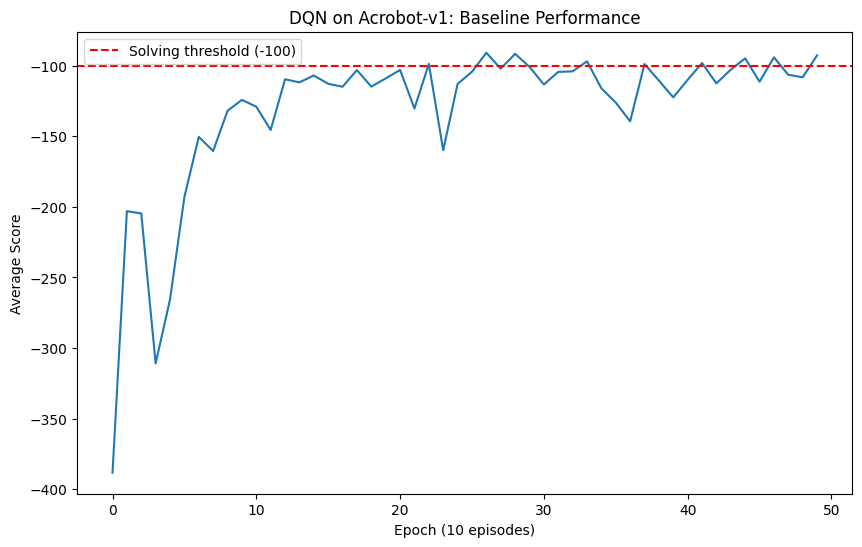

In [6]:
print("\n--- Running baseline with default parameters ---")
baseline_scores, baseline_epochs = train(num_episodes=500)

plt.figure(figsize=(10, 6))
plt.plot(range(len(baseline_epochs)), baseline_epochs)
plt.title('DQN on Acrobot-v1: Baseline Performance')
plt.xlabel('Epoch (10 episodes)')
plt.ylabel('Average Score')
plt.axhline(y=-100, color='r', linestyle='--', label='Solving threshold (-100)')
plt.legend()
plt.savefig('dqn_acrobot_baseline.png')
plt.show()

original_target_update = TARGET_UPDATE_FREQ
original_replay_size = REPLAY_MEMORY_SIZE
original_epsilon_decay = EPSILON_DECAY_STEPS
original_learning_rate = LEARNING_RATE


TARGET UPDATE FREQUENCY


--- Testing different TARGET_UPDATE_FREQ values ---
Running with TARGET_UPDATE_FREQ = 50
Starting DQN training for Acrobot-v1
Epoch 1, Average score: -309.90, Epsilon: 0.100, steps: 3107
Epoch 2, Average score: -242.40, Epsilon: 0.100, steps: 5540
Epoch 3, Average score: -211.00, Epsilon: 0.100, steps: 7660
Epoch 4, Average score: -163.50, Epsilon: 0.100, steps: 9305
Epoch 5, Average score: -143.60, Epsilon: 0.100, steps: 10751
Epoch 6, Average score: -163.70, Epsilon: 0.100, steps: 12397
Epoch 7, Average score: -128.00, Epsilon: 0.100, steps: 13687
Epoch 8, Average score: -130.00, Epsilon: 0.100, steps: 14997
Epoch 9, Average score: -139.50, Epsilon: 0.100, steps: 16402
Epoch 10, Average score: -120.80, Epsilon: 0.100, steps: 17620
Episode 100	Average Score (100 episodes): -175.24
Epoch 11, Average score: -183.50, Epsilon: 0.100, steps: 19465
Epoch 12, Average score: -145.10, Epsilon: 0.100, steps: 20926
Epoch 13, Average score: -175.10, Epsilon: 0.100, steps: 22686
Epoch 14, Average

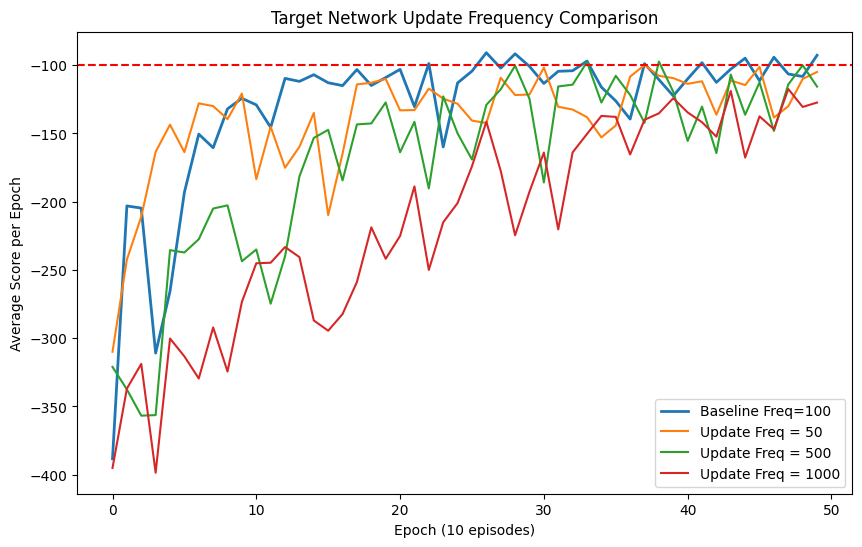

In [8]:
print("\n--- Testing different TARGET_UPDATE_FREQ values ---")
update_freqs = [50, 500, 1000]
plt.figure(figsize=(10, 6))

plt.plot(range(len(baseline_epochs)), baseline_epochs, label=f"Baseline Freq={original_target_update}", linewidth=2, linestyle='-')

for freq in update_freqs:
    print(f"Running with TARGET_UPDATE_FREQ = {freq}")
    TARGET_UPDATE_FREQ = freq
    scores, epoch_scores = train(num_episodes=500)

    plt.plot(range(len(epoch_scores)), epoch_scores, label=f"Update Freq = {freq}")
    print(f"  Final avg score: {np.mean(scores[-100:]):.2f}")

plt.title('Target Network Update Frequency Comparison')
plt.xlabel('Epoch (10 episodes)')
plt.ylabel('Average Score per Epoch')
plt.legend()
plt.axhline(y=-100, color='r', linestyle='--')
plt.savefig('acrobot_target_update_sensitivity.png')
plt.show()

TARGET_UPDATE_FREQ = original_target_update

Replay Memory Size


--- Testing different REPLAY_MEMORY_SIZE values ---
Running with REPLAY_MEMORY_SIZE = 1000
Starting DQN training for Acrobot-v1
Epoch 1, Average score: -353.50, Epsilon: 0.100, steps: 3543
Epoch 2, Average score: -181.60, Epsilon: 0.100, steps: 5369
Epoch 3, Average score: -173.80, Epsilon: 0.100, steps: 7117
Epoch 4, Average score: -163.60, Epsilon: 0.100, steps: 8763
Epoch 5, Average score: -161.60, Epsilon: 0.100, steps: 10389
Epoch 6, Average score: -131.30, Epsilon: 0.100, steps: 11712
Epoch 7, Average score: -158.50, Epsilon: 0.100, steps: 13307
Epoch 8, Average score: -142.90, Epsilon: 0.100, steps: 14746
Epoch 9, Average score: -118.90, Epsilon: 0.100, steps: 15945
Epoch 10, Average score: -114.80, Epsilon: 0.100, steps: 17103
Episode 100	Average Score (100 episodes): -170.05
Epoch 11, Average score: -108.60, Epsilon: 0.100, steps: 18199
Epoch 12, Average score: -99.30, Epsilon: 0.100, steps: 19202
Epoch 13, Average score: -130.00, Epsilon: 0.100, steps: 20512
Epoch 14, Averag

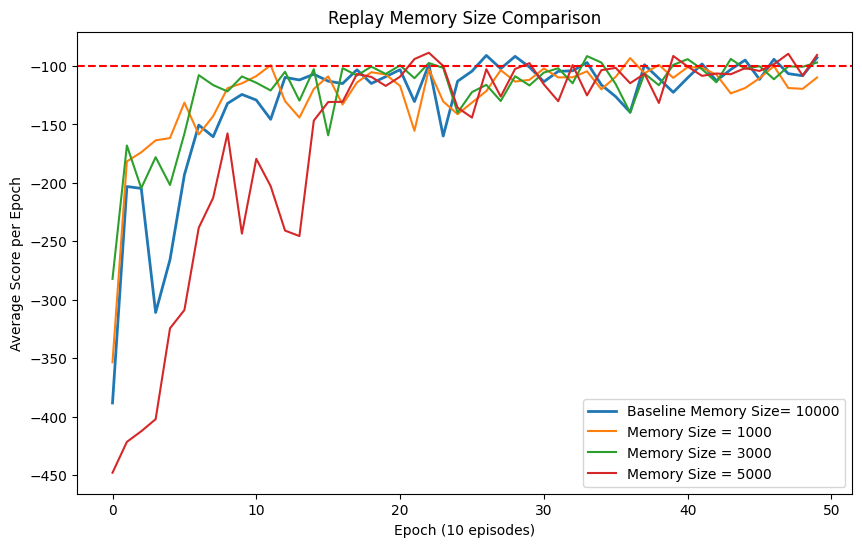

In [9]:
print("\n--- Testing different REPLAY_MEMORY_SIZE values ---")
memory_sizes = [1000, 3000, 5000]
plt.figure(figsize=(10, 6))

plt.plot(range(len(baseline_epochs)), baseline_epochs, label=f"Baseline Memory Size= {original_replay_size}", linewidth=2, linestyle='-')

for size in memory_sizes:
    print(f"Running with REPLAY_MEMORY_SIZE = {size}")
    REPLAY_MEMORY_SIZE = size
    agent = DQNAgent()
    scores, epoch_scores = train(num_episodes=500,agent=agent)

    plt.plot(range(len(epoch_scores)), epoch_scores, label=f"Memory Size = {size}")
    print(f"  Final avg score: {np.mean(scores[-100:]):.2f}")

plt.title('Replay Memory Size Comparison')
plt.xlabel('Epoch (10 episodes)')
plt.ylabel('Average Score per Epoch')
plt.legend()
plt.axhline(y=-100, color='r', linestyle='--')
plt.savefig('acrobot_memory_size_sensitivity.png')
plt.show()

# Reset value
REPLAY_MEMORY_SIZE = original_replay_size

Epsilon Decay steps


--- Testing different EPSILON_DECAY_STEPS values ---
Running with EPSILON_DECAY_STEPS = 500
Starting DQN training for Acrobot-v1
Epoch 1, Average score: -386.30, Epsilon: 0.100, steps: 3871
Epoch 2, Average score: -273.80, Epsilon: 0.100, steps: 6619
Epoch 3, Average score: -232.80, Epsilon: 0.100, steps: 8957
Epoch 4, Average score: -170.90, Epsilon: 0.100, steps: 10676
Epoch 5, Average score: -205.40, Epsilon: 0.100, steps: 12739
Epoch 6, Average score: -208.90, Epsilon: 0.100, steps: 14838
Epoch 7, Average score: -221.10, Epsilon: 0.100, steps: 17059
Epoch 8, Average score: -210.20, Epsilon: 0.100, steps: 19170
Epoch 9, Average score: -177.00, Epsilon: 0.100, steps: 20950
Epoch 10, Average score: -179.00, Epsilon: 0.100, steps: 22750
Episode 100	Average Score (100 episodes): -226.54
Epoch 11, Average score: -156.70, Epsilon: 0.100, steps: 24327
Epoch 12, Average score: -139.90, Epsilon: 0.100, steps: 25736
Epoch 13, Average score: -120.80, Epsilon: 0.100, steps: 26954
Epoch 14, Ave

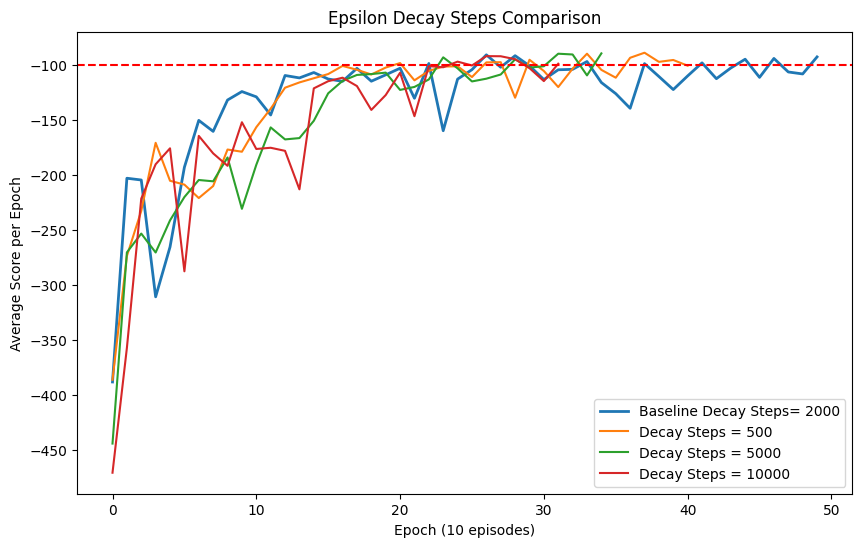

In [10]:
print("\n--- Testing different EPSILON_DECAY_STEPS values ---")
decay_steps = [500, 5000, 10000]
plt.figure(figsize=(10, 6))
plt.plot(range(len(baseline_epochs)), baseline_epochs, label=f"Baseline Decay Steps= {original_epsilon_decay}", linewidth=2, linestyle='-')
for steps in decay_steps:
    print(f"Running with EPSILON_DECAY_STEPS = {steps}")
    EPSILON_DECAY_STEPS = steps
    scores, epoch_scores = train(num_episodes=500)

    plt.plot(range(len(epoch_scores)), epoch_scores, label=f"Decay Steps = {steps}")
    print(f"  Final avg score: {np.mean(scores[-100:]):.2f}")

plt.title('Epsilon Decay Steps Comparison')
plt.xlabel('Epoch (10 episodes)')
plt.ylabel('Average Score per Epoch')
plt.legend()
plt.axhline(y=-100, color='r', linestyle='--')
plt.savefig('acrobot_epsilon_decay_sensitivity.png')
plt.show()

# Reset value
EPSILON_DECAY_STEPS = original_epsilon_decay

Learning Rate


--- Testing different LEARNING_RATE values ---
Running with LEARNING_RATE = 1e-05
Starting DQN training for Acrobot-v1
Epoch 1, Average score: -394.30, Epsilon: 0.100, steps: 3947
Epoch 2, Average score: -151.80, Epsilon: 0.100, steps: 5475
Epoch 3, Average score: -127.30, Epsilon: 0.100, steps: 6758
Epoch 4, Average score: -158.30, Epsilon: 0.100, steps: 8351
Epoch 5, Average score: -316.80, Epsilon: 0.100, steps: 11526
Epoch 6, Average score: -467.00, Epsilon: 0.100, steps: 16199
Epoch 7, Average score: -152.40, Epsilon: 0.100, steps: 17733
Epoch 8, Average score: -162.30, Epsilon: 0.100, steps: 19366
Epoch 9, Average score: -126.80, Epsilon: 0.100, steps: 20644
Epoch 10, Average score: -117.20, Epsilon: 0.100, steps: 21826
Episode 100	Average Score (100 episodes): -217.42
Epoch 11, Average score: -133.30, Epsilon: 0.100, steps: 23169
Epoch 12, Average score: -130.40, Epsilon: 0.100, steps: 24483
Epoch 13, Average score: -136.50, Epsilon: 0.100, steps: 25858
Epoch 14, Average score:

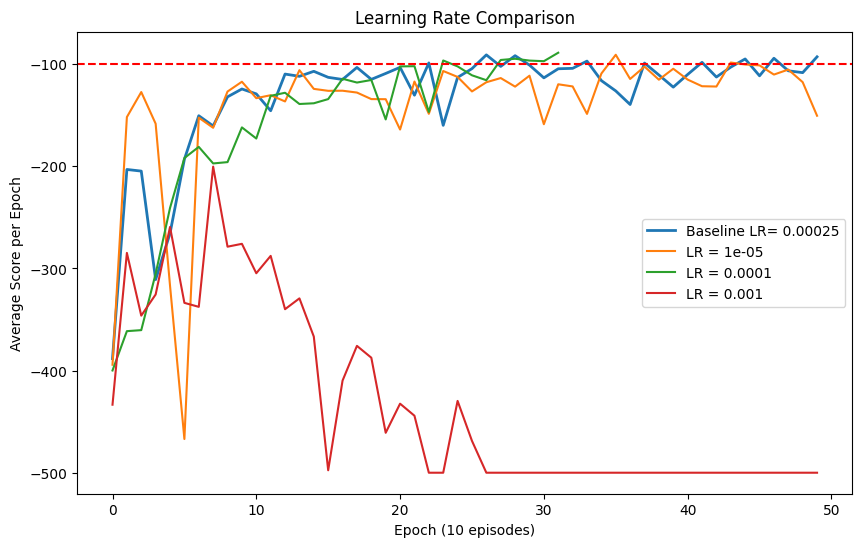

In [11]:
print("\n--- Testing different LEARNING_RATE values ---")
learning_rates = [0.00001, 0.0001, 0.001]
plt.figure(figsize=(10, 6))
plt.plot(range(len(baseline_epochs)), baseline_epochs, label=f"Baseline LR= {original_learning_rate}", linewidth=2, linestyle='-')
for lr in learning_rates:
    print(f"Running with LEARNING_RATE = {lr}")
    LEARNING_RATE = lr
    agent = DQNAgent()
    scores, epoch_scores = train(num_episodes=500, agent=agent)

    plt.plot(range(len(epoch_scores)), epoch_scores, label=f"LR = {lr}")
    print(f"  Final avg score: {np.mean(scores[-100:]):.2f}")

plt.title('Learning Rate Comparison')
plt.xlabel('Epoch (10 episodes)')
plt.ylabel('Average Score per Epoch')
plt.legend()
plt.axhline(y=-100, color='r', linestyle='--')
plt.savefig('acrobot_learning_rate_sensitivity.png')
plt.show()

# Reset value
LEARNING_RATE = original_learning_rate

In [12]:
# Reset all values and close environment
TARGET_UPDATE_FREQ = original_target_update
REPLAY_MEMORY_SIZE = original_replay_size
EPSILON_DECAY_STEPS = original_epsilon_decay
LEARNING_RATE = original_learning_rate
env.close()